# Figure Generation — ErrP Meta-Learning Paper

Generates all publication figures from the result CSVs under `Results/`.
Run top to bottom. Figures are written to `figures/` as both **PNG (300 dpi)**
for previewing and **PDF (vector)** for LaTeX `\includegraphics`.

Datasets / ablations consumed:
- `Results/Primery/seed_*`        — primary INRIA benchmark
- `Results/Validation/seed_*`     — coadaptation cross-dataset validation
- `Results/Class wighted/`        — class-weighted vs uniform episodic loss
- `Results/FiLM vs NoFiLM/`       — FiLM ablation
- `Results/Feature Representation/seed_*` — engineered vs raw features

If your folder is elsewhere, edit `RESULTS_ROOT` in the config cell.

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

warnings.simplefilter('ignore')

# ---- Paths (edit RESULTS_ROOT if needed) --------------------------------
RESULTS_ROOT = 'Results'
FIG_DIR      = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

PRIMARY_DIR    = os.path.join(RESULTS_ROOT, 'Primery')
VALIDATION_DIR = os.path.join(RESULTS_ROOT, 'Validation')
CLASSW_DIR     = os.path.join(RESULTS_ROOT, 'Class wighted')
FILM_DIR       = os.path.join(RESULTS_ROOT, 'FiLM vs NoFiLM')
FEAT_DIR       = os.path.join(RESULTS_ROOT, 'Feature Representation')

SEEDS = [42, 123, 456]
KS    = [5, 10, 20]

# Display order (best -> worst, by validation K=5) and consistent colors
METHOD_ORDER = ['Reptile', 'SubjectConditioned', 'MAML-ANIL', 'Full-MAML',
                'Prototypical', 'EEGNet', 'Matching',
                'Riemannian', 'CovarianceAlignment', 'Supervised']

METHOD_COLORS = {
    'Reptile':             '#1f77b4',
    'SubjectConditioned':  '#ff7f0e',
    'MAML-ANIL':           '#2ca02c',
    'Full-MAML':           '#d62728',
    'Prototypical':        '#9467bd',
    'EEGNet':              '#8c564b',
    'Matching':            '#e377c2',
    'Riemannian':          '#7f7f7f',
    'CovarianceAlignment': '#bcbd22',
    'Supervised':          '#17becf',
}

# Short labels for crowded axes
METHOD_LABEL = {
    'Reptile': 'Reptile', 'SubjectConditioned': 'Subj-Cond (FiLM)',
    'MAML-ANIL': 'MAML-ANIL', 'Full-MAML': 'MAML',
    'Prototypical': 'ProtoNet', 'EEGNet': 'EEGNet', 'Matching': 'Matching',
    'Riemannian': 'Riemannian', 'CovarianceAlignment': 'Cov-Align',
    'Supervised': 'Supervised',
}

# ---- Publication style ---------------------------------------------------
mpl.rcParams.update({
    'figure.dpi':        120,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'font.size':         10,
    'font.family':       'serif',
    'axes.titlesize':    11,
    'axes.labelsize':    10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'legend.fontsize':   8,
    'legend.frameon':    False,
})


def save_fig(fig, name):
    """Save a figure as both PNG and PDF into FIG_DIR."""
    png = os.path.join(FIG_DIR, name + '.png')
    pdf = os.path.join(FIG_DIR, name + '.pdf')
    fig.savefig(png)
    fig.savefig(pdf)
    print(f'  saved {png}  and  {pdf}')

## Loaders

`load_aggregate` reads each method's `*_aggregate.csv` across seeds and returns
per-(method, K) mean and std of a chosen metric. `load_per_subject` returns
per-subject metrics averaged across seeds for the responder analysis.

In [2]:
def load_aggregate(results_dir, methods, metric='balanced_accuracy'):
    """Return DataFrame[method, k, mean, std, n_seeds] aggregated across SEEDS."""
    rows = []
    for m in methods:
        for k in KS:
            vals = []
            for s in SEEDS:
                fp = os.path.join(results_dir, f'seed_{s}', f'{m}_aggregate.csv')
                if not os.path.exists(fp):
                    continue
                df = pd.read_csv(fp)
                sub = df[df['k_shots'] == k]
                col = f'{metric}_mean'
                if len(sub) and col in sub.columns:
                    vals.append(float(sub[col].values[0]))
            if vals:
                rows.append({'method': m, 'k': k, 'mean': np.mean(vals),
                             'std': np.std(vals, ddof=0), 'n_seeds': len(vals)})
    return pd.DataFrame(rows)


def load_per_subject(results_dir, method, k, metric='balanced_accuracy'):
    """Return {subject_id: mean_metric_across_seeds} for one method at one K."""
    acc = {}
    cnt = {}
    for s in SEEDS:
        fp = os.path.join(results_dir, f'seed_{s}', f'{method}_per_subject.csv')
        if not os.path.exists(fp):
            continue
        df = pd.read_csv(fp)
        sub = df[df['k_shots'] == k]
        for _, r in sub.iterrows():
            sid = r['subject_id']
            acc[sid] = acc.get(sid, 0.0) + float(r[metric])
            cnt[sid] = cnt.get(sid, 0) + 1
    return {sid: acc[sid] / cnt[sid] for sid in acc}


def load_combined(path):
    """Load a combined_results_all_seeds.csv if present, else None."""
    fp = os.path.join(path, 'combined_results_all_seeds.csv')
    return pd.read_csv(fp) if os.path.exists(fp) else None


# Sanity check what was found
for name, d in [('Primary', PRIMARY_DIR), ('Validation', VALIDATION_DIR)]:
    agg = load_aggregate(d, METHOD_ORDER)
    print(f'{name}: {agg["method"].nunique()} methods, '
          f'{agg["n_seeds"].max()} seeds max')

Primary: 10 methods, 3 seeds max
Validation: 10 methods, 3 seeds max


## Figure 1 — Main comparison (grouped bars)

Balanced accuracy per method, grouped by K, with std error bars across seeds.
Two panels: primary INRIA and cross-dataset validation. **This is the headline figure.**

  saved figures\fig1_main_comparison.png  and  figures\fig1_main_comparison.pdf


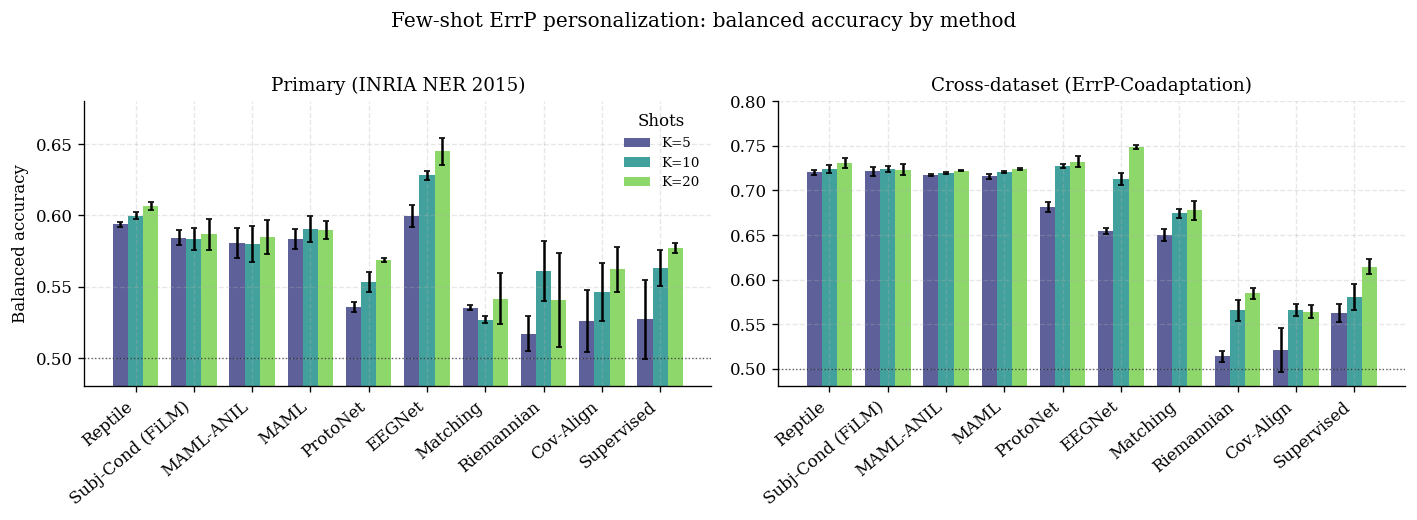

In [3]:
def fig_main_bars(metric='balanced_accuracy', fname='fig1_main_comparison'):
    primary = load_aggregate(PRIMARY_DIR, METHOD_ORDER, metric)
    valid   = load_aggregate(VALIDATION_DIR, METHOD_ORDER, metric)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)
    panels = [('Primary (INRIA NER 2015)', primary),
              ('Cross-dataset (ErrP-Coadaptation)', valid)]
    bar_w = 0.26
    x = np.arange(len(METHOD_ORDER))

    for ax, (title, data) in zip(axes, panels):
        for i, k in enumerate(KS):
            means = [data[(data.method == m) & (data.k == k)]['mean'].values
                     for m in METHOD_ORDER]
            stds  = [data[(data.method == m) & (data.k == k)]['std'].values
                     for m in METHOD_ORDER]
            means = [v[0] if len(v) else np.nan for v in means]
            stds  = [v[0] if len(v) else 0.0 for v in stds]
            ax.bar(x + (i - 1) * bar_w, means, bar_w, yerr=stds, capsize=2,
                   label=f'K={k}', alpha=0.85,
                   color=plt.cm.viridis(0.2 + 0.3 * i))
        ax.axhline(0.5, color='k', lw=0.8, ls=':', alpha=0.6)
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels([METHOD_LABEL[m] for m in METHOD_ORDER],
                           rotation=40, ha='right')
        ax.set_ylim(0.48, 0.68 if 'Primary' in title else 0.80)
    axes[0].set_ylabel('Balanced accuracy')
    axes[0].legend(title='Shots', loc='upper right')
    fig.suptitle('Few-shot ErrP personalization: balanced accuracy by method',
                 y=1.02, fontsize=12)
    fig.tight_layout()
    save_fig(fig, fname)
    return fig

_ = fig_main_bars()
plt.show()

## Figure 2 — Adaptation curves (accuracy vs K)

Balanced accuracy as a function of shot count, one line per method, shaded
std band across seeds. Shows the "late bloomer" pattern (EEGNet, ProtoNet).

  saved figures\fig2_adaptation_curves.png  and  figures\fig2_adaptation_curves.pdf


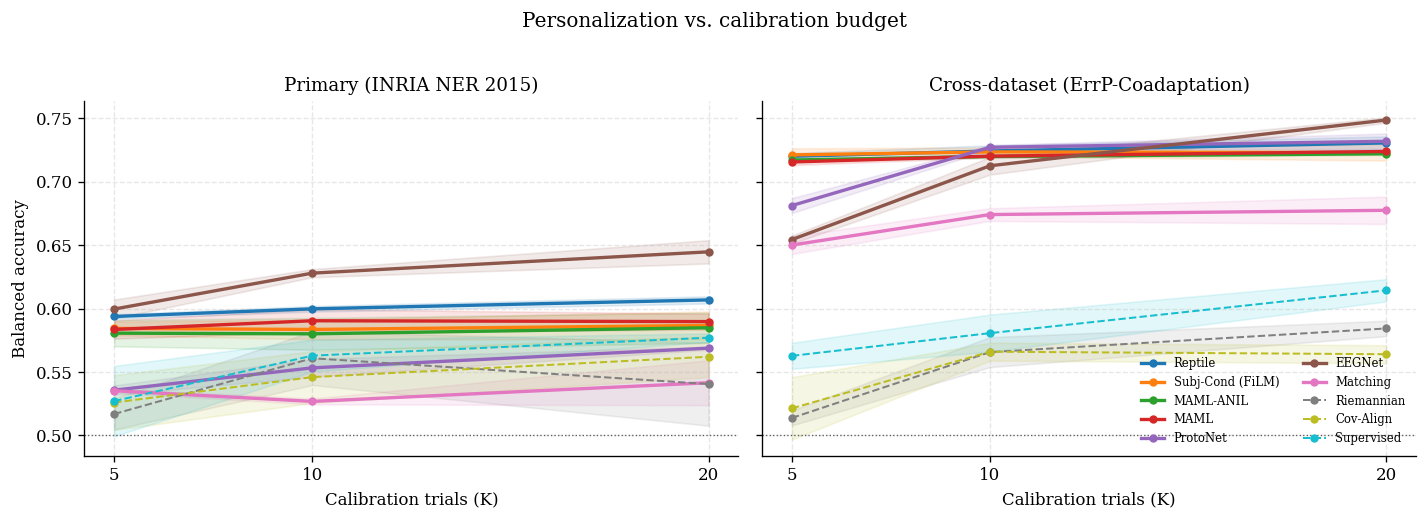

In [4]:
def fig_adaptation_curves(metric='balanced_accuracy', fname='fig2_adaptation_curves'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
    panels = [('Primary (INRIA NER 2015)', PRIMARY_DIR),
              ('Cross-dataset (ErrP-Coadaptation)', VALIDATION_DIR)]

    for ax, (title, d) in zip(axes, panels):
        agg = load_aggregate(d, METHOD_ORDER, metric)
        for m in METHOD_ORDER:
            sub = agg[agg.method == m].sort_values('k')
            if not len(sub):
                continue
            ls = '--' if m in ('Supervised', 'Riemannian', 'CovarianceAlignment') else '-'
            lw = 1.2 if ls == '--' else 2.0
            ax.plot(sub['k'], sub['mean'], ls, lw=lw, marker='o', ms=4,
                    color=METHOD_COLORS[m], label=METHOD_LABEL[m])
            ax.fill_between(sub['k'], sub['mean'] - sub['std'],
                            sub['mean'] + sub['std'],
                            color=METHOD_COLORS[m], alpha=0.12)
        ax.axhline(0.5, color='k', lw=0.8, ls=':', alpha=0.6)
        ax.set_title(title)
        ax.set_xlabel('Calibration trials (K)')
        ax.set_xticks(KS)
    axes[0].set_ylabel('Balanced accuracy')
    axes[1].legend(loc='lower right', ncol=2, fontsize=7)
    fig.suptitle('Personalization vs. calibration budget', y=1.02, fontsize=12)
    fig.tight_layout()
    save_fig(fig, fname)
    return fig

_ = fig_adaptation_curves()
plt.show()

## Figure 3 — Improvement over supervised baseline (K=5)

Per-method Δ balanced accuracy over the Supervised baseline at K=5, both
datasets. Positive = beats supervised. Error bars are std across seeds.

  saved figures\fig3_delta_over_supervised.png  and  figures\fig3_delta_over_supervised.pdf


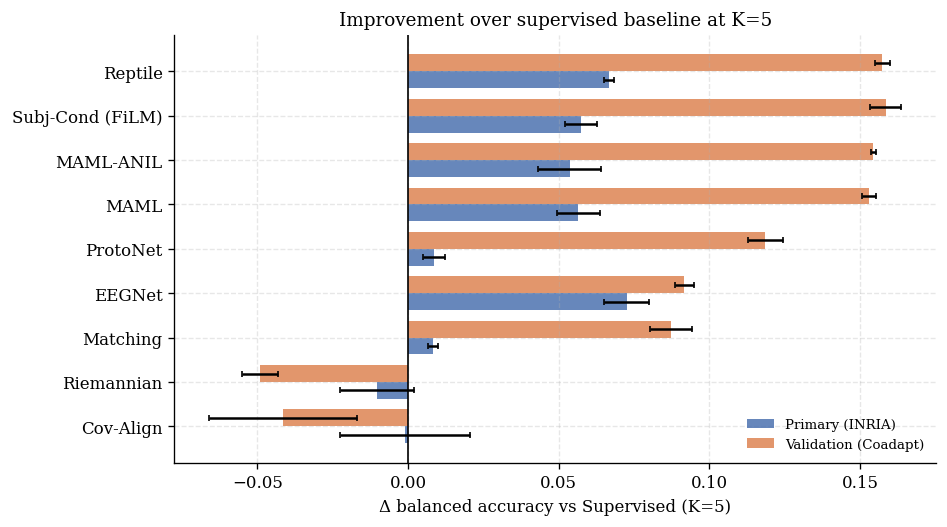

In [5]:
def fig_delta_over_supervised(k=5, metric='balanced_accuracy',
                              fname='fig3_delta_over_supervised'):
    primary = load_aggregate(PRIMARY_DIR, METHOD_ORDER, metric)
    valid   = load_aggregate(VALIDATION_DIR, METHOD_ORDER, metric)

    def deltas(data):
        base = data[(data.method == 'Supervised') & (data.k == k)]['mean'].values
        base = base[0] if len(base) else np.nan
        out = []
        for m in METHOD_ORDER:
            if m == 'Supervised':
                continue
            row = data[(data.method == m) & (data.k == k)]
            if len(row):
                out.append((m, row['mean'].values[0] - base, row['std'].values[0]))
        return out

    methods_no_sup = [m for m in METHOD_ORDER if m != 'Supervised']
    y = np.arange(len(methods_no_sup))
    pr = {m: (d, s) for m, d, s in deltas(primary)}
    va = {m: (d, s) for m, d, s in deltas(valid)}

    fig, ax = plt.subplots(figsize=(8, 4.5))
    h = 0.38
    ax.barh(y + h / 2, [pr.get(m, (np.nan, 0))[0] for m in methods_no_sup], h,
            xerr=[pr.get(m, (0, 0))[1] for m in methods_no_sup], capsize=2,
            color='#4C72B0', label='Primary (INRIA)', alpha=0.85)
    ax.barh(y - h / 2, [va.get(m, (np.nan, 0))[0] for m in methods_no_sup], h,
            xerr=[va.get(m, (0, 0))[1] for m in methods_no_sup], capsize=2,
            color='#DD8452', label='Validation (Coadapt)', alpha=0.85)
    ax.axvline(0, color='k', lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels([METHOD_LABEL[m] for m in methods_no_sup])
    ax.invert_yaxis()
    ax.set_xlabel(f'Δ balanced accuracy vs Supervised (K={k})')
    ax.set_title(f'Improvement over supervised baseline at K={k}')
    ax.legend(loc='lower right')
    fig.tight_layout()
    save_fig(fig, fname)
    return fig

_ = fig_delta_over_supervised()
plt.show()

## Figure 4 — Ablations

Three panels: (a) class-weighted vs uniform episodic loss, (b) FiLM vs no-FiLM,
(c) engineered vs raw features. Balanced accuracy across K, std across seeds.

  saved figures\fig4_ablations.png  and  figures\fig4_ablations.pdf


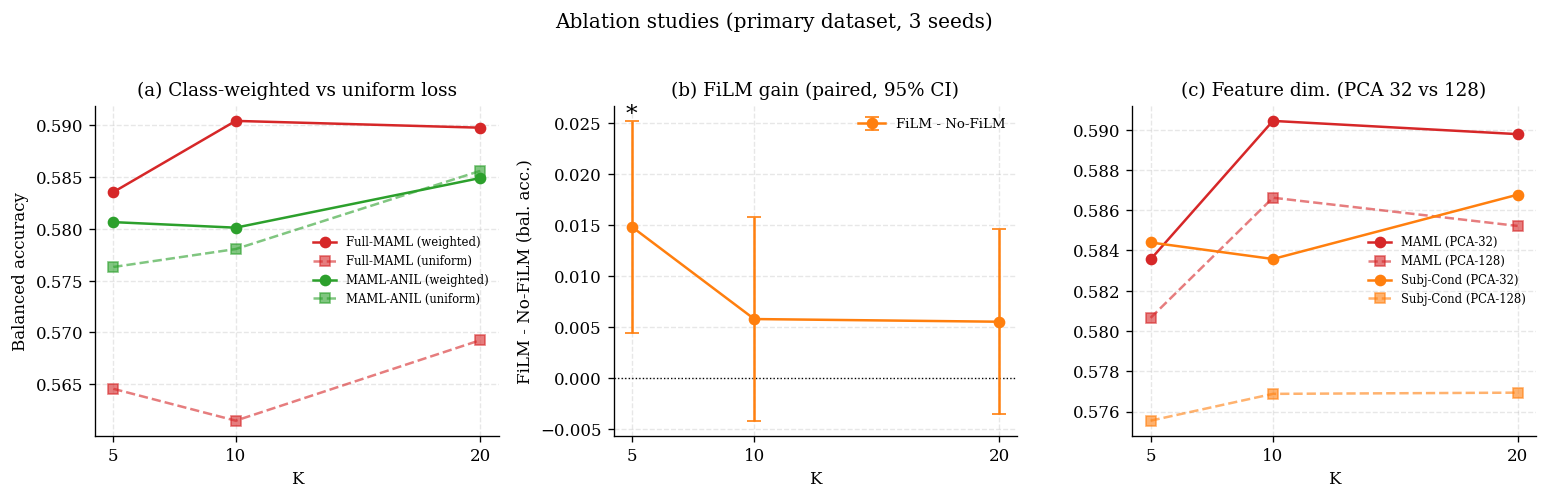

In [6]:
def _combined_means(df, method, metric='balanced_accuracy'):
    """Pull mean/std per K from a combined_results_all_seeds.csv frame."""
    out = {}
    for k in KS:
        row = df[(df.method == method) & (df.k_shots == k)]
        if len(row):
            out[k] = (float(row[f'{metric}_mean'].values[0]),
                      float(row[f'{metric}_std'].values[0]))
    return out


def fig_ablations(metric='balanced_accuracy', fname='fig4_ablations'):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
    x = np.arange(len(KS))
    bw = 0.38

    # (a) Class weighting
    cw = load_combined(CLASSW_DIR)
    ax = axes[0]
    if cw is not None:
        pairs = [('Full-MAML', 'Full-MAML-Uniform', '#d62728'),
                 ('MAML-ANIL', 'MAML-ANIL-Uniform', '#2ca02c')]
        off = -bw / 2
        for wname, uname, col in pairs:
            wm = _combined_means(cw, wname, metric)
            um = _combined_means(cw, uname, metric)
            ax.plot(KS, [wm[k][0] for k in KS], '-o', color=col,
                    label=f'{wname} (weighted)')
            ax.plot(KS, [um[k][0] for k in KS], '--s', color=col, alpha=0.6,
                    label=f'{wname} (uniform)')
    ax.set_title('(a) Class-weighted vs uniform loss')
    ax.set_xlabel('K'); ax.set_xticks(KS); ax.legend(fontsize=7)
    ax.set_ylabel('Balanced accuracy')

    # (b) FiLM -- PAIRED difference (FiLM - No-FiLM) with 95% CI; matches the
    # within-subject Wilcoxon test (marginal CIs would misleadingly overlap).
    ax = axes[1]
    md=[]; lo=[]; hi=[]
    for k in KS:
        A=load_per_subject(FILM_DIR,'SubjectConditioned',k,metric)
        B=load_per_subject(FILM_DIR,'SubjectConditioned_NoFiLM',k,metric)
        subs=sorted(set(A)&set(B)); d=np.array([A[s]-B[s] for s in subs])
        m=d.mean(); h=1.96*d.std(ddof=1)/np.sqrt(len(d))
        md.append(m); lo.append(m-h); hi.append(m+h)
    md=np.array(md)
    ax.axhline(0, color='k', lw=0.8, ls=':')
    ax.errorbar(KS, md, yerr=[md-np.array(lo), np.array(hi)-md], fmt='-o',
                color='#ff7f0e', capsize=4, label='FiLM - No-FiLM')
    ax.annotate('*', xy=(KS[0], hi[0]), ha='center', fontsize=14)
    ax.set_title('(b) FiLM gain (paired, 95% CI)')
    ax.set_ylabel('FiLM - No-FiLM (bal. acc.)')
    ax.set_xlabel('K'); ax.set_xticks(KS); ax.legend(fontsize=8)

    # (c) Feature representation (no combined CSV -> aggregate across seeds)
    ax = axes[2]
    feat_methods = ['Full-MAML', 'Full-MAML-Raw',
                    'SubjectConditioned', 'SubjectConditioned-Raw']
    feat = load_aggregate(FEAT_DIR, feat_methods, metric)
    style = {'Full-MAML': ('-o', '#d62728', 'MAML (PCA-32)'),
             'Full-MAML-Raw': ('--s', '#d62728', 'MAML (PCA-128)'),
             'SubjectConditioned': ('-o', '#ff7f0e', 'Subj-Cond (PCA-32)'),
             'SubjectConditioned-Raw': ('--s', '#ff7f0e', 'Subj-Cond (PCA-128)')}
    for m in feat_methods:
        sub = feat[feat.method == m].sort_values('k')
        if not len(sub):
            continue
        ls, col, lab = style[m]
        alpha = 0.6 if '--' in ls else 1.0
        ax.plot(sub['k'], sub['mean'], ls, color=col, alpha=alpha, label=lab)
    ax.set_title('(c) Feature dim. (PCA 32 vs 128)')
    ax.set_xlabel('K'); ax.set_xticks(KS); ax.legend(fontsize=7)

    fig.suptitle('Ablation studies (primary dataset, 3 seeds)', y=1.03, fontsize=12)
    fig.tight_layout()
    save_fig(fig, fname)
    return fig

_ = fig_ablations()
plt.show()

## Figure 5 — Per-subject responder analysis (K=5)

Each point is one subject: x = Supervised balanced accuracy, y = best
meta-learner balanced accuracy (Reptile), averaged across seeds. Points above
the diagonal are subjects where meta-learning helps. Two datasets.

  saved figures\fig5_responder_scatter.png  and  figures\fig5_responder_scatter.pdf


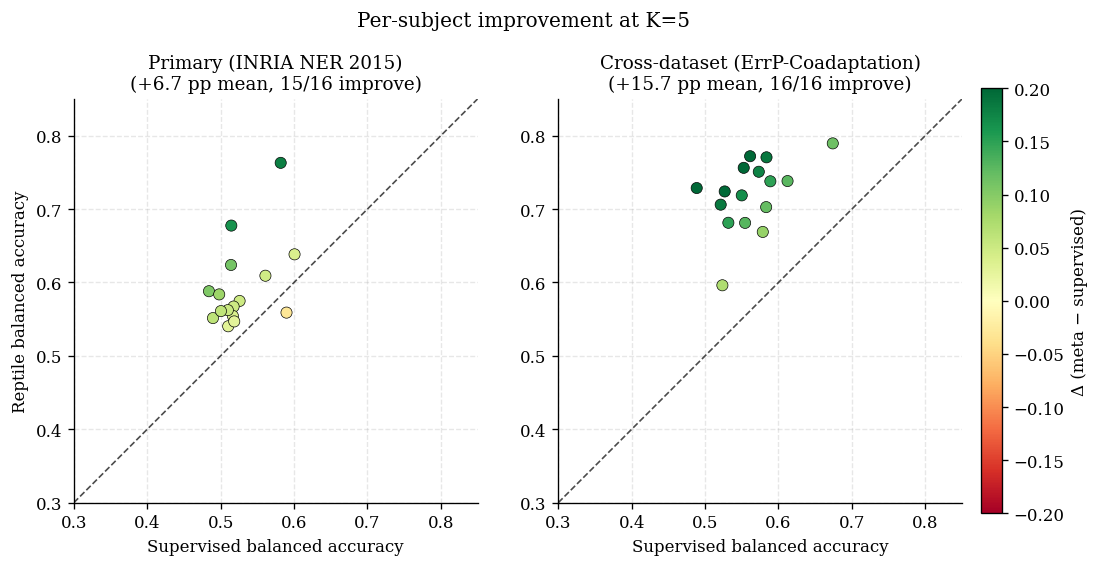

In [7]:
def fig_responder_scatter(meta_method='Reptile', k=5,
                          fname='fig5_responder_scatter'):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
    panels = [('Primary (INRIA NER 2015)', PRIMARY_DIR),
              ('Cross-dataset (ErrP-Coadaptation)', VALIDATION_DIR)]

    for ax, (title, d) in zip(axes, panels):
        sup = load_per_subject(d, 'Supervised', k)
        meta = load_per_subject(d, meta_method, k)
        common = sorted(set(sup) & set(meta))
        sx = np.array([sup[s] for s in common])
        my = np.array([meta[s] for s in common])
        gains = my - sx
        sc = ax.scatter(sx, my, c=gains, cmap='RdYlGn', vmin=-0.2, vmax=0.2,
                        s=45, edgecolor='k', linewidth=0.4, zorder=3)
        lo, hi = 0.30, 0.85
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.7)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_title(f'{title}\n(+{100*gains.mean():.1f} pp mean, '
                     f'{int((gains>0).sum())}/{len(gains)} improve)')
        ax.set_xlabel('Supervised balanced accuracy')
        ax.set_aspect('equal')
    axes[0].set_ylabel(f'{METHOD_LABEL[meta_method]} balanced accuracy')
    cbar = fig.colorbar(sc, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label('Δ (meta − supervised)')
    fig.suptitle(f'Per-subject improvement at K={k}', y=1.02, fontsize=12)
    save_fig(fig, fname)
    return fig

_ = fig_responder_scatter()
plt.show()

## Figure 6 — AUROC comparison (K=5)

AUROC is threshold-independent and robust to the 75/25 class imbalance — often
the cleaner headline metric for ErrP. Per-method AUROC at K=5, both datasets.

  saved figures\fig6_auroc.png  and  figures\fig6_auroc.pdf


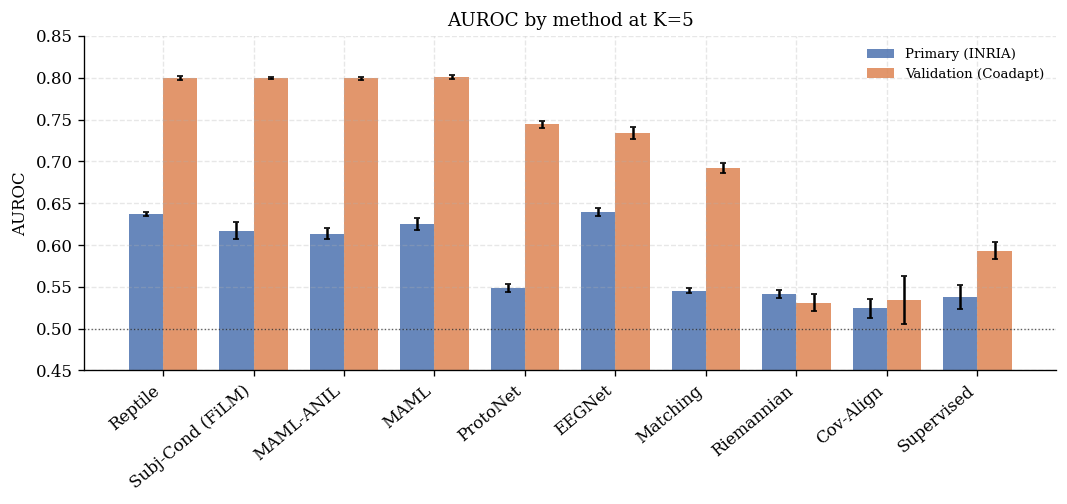

In [8]:
def fig_auroc(k=5, fname='fig6_auroc'):
    primary = load_aggregate(PRIMARY_DIR, METHOD_ORDER, 'auroc')
    valid   = load_aggregate(VALIDATION_DIR, METHOD_ORDER, 'auroc')
    x = np.arange(len(METHOD_ORDER))
    bw = 0.38

    def col(data, m):
        r = data[(data.method == m) & (data.k == k)]
        return (r['mean'].values[0], r['std'].values[0]) if len(r) else (np.nan, 0)

    fig, ax = plt.subplots(figsize=(9, 4.3))
    ax.bar(x - bw/2, [col(primary, m)[0] for m in METHOD_ORDER], bw,
           yerr=[col(primary, m)[1] for m in METHOD_ORDER], capsize=2,
           color='#4C72B0', label='Primary (INRIA)', alpha=0.85)
    ax.bar(x + bw/2, [col(valid, m)[0] for m in METHOD_ORDER], bw,
           yerr=[col(valid, m)[1] for m in METHOD_ORDER], capsize=2,
           color='#DD8452', label='Validation (Coadapt)', alpha=0.85)
    ax.axhline(0.5, color='k', lw=0.8, ls=':', alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_LABEL[m] for m in METHOD_ORDER],
                       rotation=40, ha='right')
    ax.set_ylim(0.45, 0.85)
    ax.set_ylabel('AUROC')
    ax.set_title(f'AUROC by method at K={k}')
    ax.legend()
    fig.tight_layout()
    save_fig(fig, fname)
    return fig

_ = fig_auroc()
plt.show()

## Figure 7 — Fair-transfer baselines (data-access control, K=5)

  saved figures\fig7_fair_baselines.png  and  figures\fig7_fair_baselines.pdf


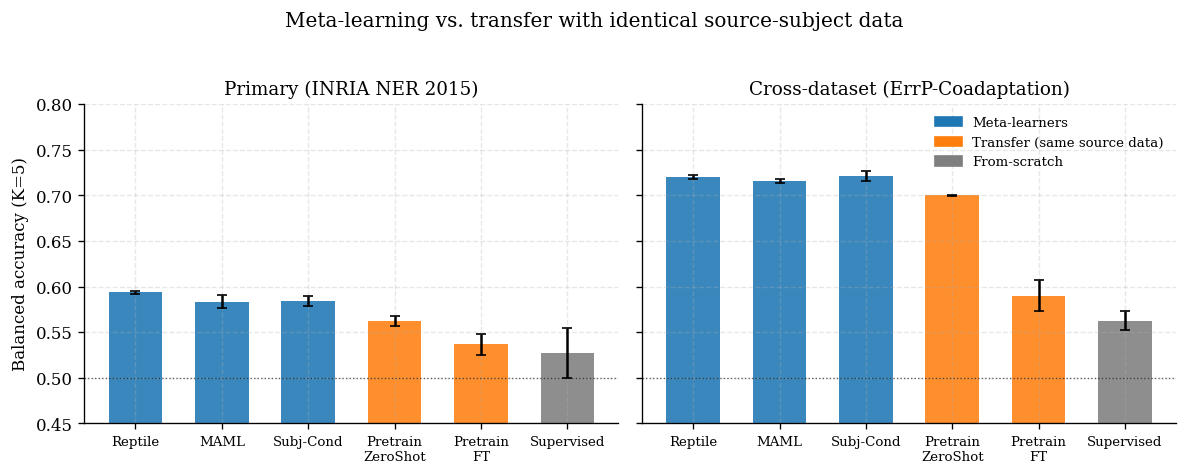

In [9]:
def fig_fair_baselines(k=5, fname='fig7_fair_baselines'):
    """Visualize the data-access control: meta-learners vs two transfer
    baselines that pretrain on the SAME source subjects, plus from-scratch."""
    order  = ['Reptile', 'Full-MAML', 'SubjectConditioned',
              'Pretrain-ZeroShot', 'Pretrain-FT', 'Supervised']
    labels = {'Reptile': 'Reptile', 'Full-MAML': 'MAML',
              'SubjectConditioned': 'Subj-Cond', 'Pretrain-ZeroShot': 'Pretrain\nZeroShot',
              'Pretrain-FT': 'Pretrain\nFT', 'Supervised': 'Supervised'}
    group  = {'Reptile': 'meta', 'Full-MAML': 'meta', 'SubjectConditioned': 'meta',
              'Pretrain-ZeroShot': 'transfer', 'Pretrain-FT': 'transfer',
              'Supervised': 'scratch'}
    gcolor = {'meta': '#1f77b4', 'transfer': '#ff7f0e', 'scratch': '#7f7f7f'}

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
    panels = [('Primary (INRIA NER 2015)', PRIMARY_DIR),
              ('Cross-dataset (ErrP-Coadaptation)', VALIDATION_DIR)]
    for ax, (title, d) in zip(axes, panels):
        agg = load_aggregate(d, order)
        means = [agg[(agg.method == m) & (agg.k == k)]['mean'].values for m in order]
        stds  = [agg[(agg.method == m) & (agg.k == k)]['std'].values for m in order]
        means = [v[0] if len(v) else np.nan for v in means]
        stds  = [v[0] if len(v) else 0.0 for v in stds]
        x = np.arange(len(order))
        ax.bar(x, means, 0.62, yerr=stds, capsize=3, alpha=0.88,
               color=[gcolor[group[m]] for m in order])
        ax.axhline(0.5, color='k', lw=0.8, ls=':', alpha=0.6)
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels([labels[m] for m in order], fontsize=8)
        ax.set_ylim(0.45, 0.80)
    axes[0].set_ylabel(f'Balanced accuracy (K={k})')
    handles = [Patch(color=gcolor['meta'],     label='Meta-learners'),
               Patch(color=gcolor['transfer'], label='Transfer (same source data)'),
               Patch(color=gcolor['scratch'],  label='From-scratch')]
    axes[1].legend(handles=handles, loc='upper right')
    fig.suptitle('Meta-learning vs. transfer with identical source-subject data',
                 y=1.03, fontsize=12)
    fig.tight_layout()
    save_fig(fig, fname)
    return fig


_ = fig_fair_baselines()
plt.show()

## Done

All figures are in `figures/` as `.png` (preview) and `.pdf` (LaTeX).
Recommended mapping to paper:
- **Fig 1** (`fig1_main_comparison`) — main results figure
- **Fig 2** (`fig2_adaptation_curves`) — personalization vs budget
- **Fig 3** (`fig3_delta_over_supervised`) — improvement over baseline
- **Fig 4** (`fig4_ablations`) — ablation panel
- **Fig 5** (`fig5_responder_scatter`) — per-subject analysis
- **Fig 6** (`fig6_auroc`) — AUROC comparison (use if you headline AUROC)

For LaTeX, include the PDF: `\includegraphics[width=\columnwidth]{figures/fig1_main_comparison.pdf}`

In [10]:
print('Figures generated:')
for f in sorted(os.listdir(FIG_DIR)):
    print('  ', f)

Figures generated:
   fig1_main_comparison.pdf
   fig1_main_comparison.png
   fig2_adaptation_curves.pdf
   fig2_adaptation_curves.png
   fig3_delta_over_supervised.pdf
   fig3_delta_over_supervised.png
   fig4_ablations.pdf
   fig4_ablations.png
   fig5_responder_scatter.pdf
   fig5_responder_scatter.png
   fig6_auroc.pdf
   fig6_auroc.png
   fig7_fair_baselines.pdf
   fig7_fair_baselines.png
